# TUTORIAL: Class Estimator

This tutorial introduces the `Estimator` class hierarchy and shows how to instantiate an estimator and run the forecast step.

The **analysis step** (Bayesian update with observations) is covered in `1_Introduction_to_real-time_DA/`.

**Contents**
1. [Class hierarchy](#hierarchy)
2. [Instantiate an ensemble estimator](#init)
3. [Inspecting the initial ensemble](#inspect)
4. [Running the forecast step](#forecast)

---
## 1. Class hierarchy <a class="anchor" id="hierarchy"></a>

All estimators share a common abstract base `Estimator` (defined in `estimators/__init__.py`).

Every estimator exposes the same interface:

| Method | What it does |
|---|---|
| `forecast_step(t_end=...)` | Advance the model (and bias, if present) to a target time |
| `analysis_step(d, Cdd)` | Bayesian update — covered in `1_Introduction_to_real-time_DA/` |
| `visualize_history(...)` | Plot observable and parameter histories |

The concrete classes live in three sub-modules:

```
Estimator                          (abstract base — estimators/__init__.py)
├── EnsembleEstimator              (ensemble Kalman filter base, abstract)
│   ├── EnKF                       stochastic, perturbed-observation
│   ├── EnSRKF                     deterministic square-root
│   └── rBA_EnKF                   regularised bias-aware
├── DeterministicEstimator         (Kalman filter with explicit covariance)
│   └── KalmanFilter
```

The intermediate bases are abstract — they declare a kernel (`_analysis_kernel`, ...) holding the pure maths — so only the leaf classes can be instantiated.

The estimator **owns**:
- a `Model` — passed at construction time; the estimator handles instantiation, ensemble generation, and the forecast loop.
- a `Bias` model (optional) — stepped forward in sync with the model during `forecast_step`.

---
## 2. Instantiate an ensemble estimator <a class="anchor" id="init"></a>

`EnsembleEstimator` is abstract, so we instantiate one of its leaf filters — here the square-root `EnSRKF` (the choice does not matter for this tutorial, which only runs the forecast step).

Pass the model **class** (or an existing instance) as `parent_model`.  All remaining keyword arguments are forwarded to the model constructor.

The estimator automatically:
1. Instantiates the model.
2. Generates the initial ensemble via `model.init_ensemble(m, std_phi, std_alpha, ...)`.
3. Reads the measurement operator `M` from the model.

Key constructor arguments:

| Argument | Description |
|---|---|
| `parent_model` | Model class or instance to use for the forecast |
| `m` | Number of ensemble members |
| `std_phi` | Initial state perturbation (fractional std) |
| `std_alpha` | Initial parameter uncertainty — `float` or `{name: (lo, hi)}` |
| `parent_bias` | Optional `Bias` instance or class |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from romda.models.physical import Lorenz63
from romda.estimators.ensembles import EnSRKF


ensemble = EnSRKF(
    parent_model=Lorenz63,
    parent_bias=None,
    m=20,
    std_phi=0.5,                     # initial state spread
    std_alpha=dict(rho=(20., 30.)),  # rho drawn uniformly from [20, 30]
    observe_dims=[0, 1, 2],
    dt=0.02,
)

ensemble.print_parameters(indent=2)


EnSRKF
  m = 20
  est_phi = True
  est_alpha = ['rho']
  est_bias = False
  Na = 1
  regularization_factor = None
  inflation_factor = 1.0
  inflation_factor_rejection = 1.002
  === Model parameters: ===
    Model class: Lorenz63
    Nq = 3
    beta = 2.666667
    observe_dims = [0, 1, 2]
    rho = 28.000000
    sigma = 10.000000
    t_lyap = 1.090513
    Ensemble configuration: {'est_alpha': ['rho'], 'm': 20}
  === Bias parameters: ===
    No bias model.


---
## 3. Inspecting the initial ensemble <a class="anchor" id="inspect"></a>

The ensemble state is stored in the model history (`model.hist`) with shape `(Nt_history, Nphi + Na, m)`.  At initialisation there is one time point.

The augmented state vector has `Nphi` physical state variables followed by `Na` estimated parameters.

In [2]:
psi0 = ensemble.current_state   # (Nphi, m)
print(f"Current state shape : {psi0.shape}")
print(f"Current time        : {ensemble.current_time}")
print(f"State mean          : {np.mean(psi0, axis=-1).round(3)}")
print(f"State std           : {np.std(psi0,  axis=-1).round(3)}")

Current state shape : (4, 20)
Current time        : 0.0
State mean          : [-11.106 -12.524  31.986  25.379]
State std           : [ 4.53   4.76  17.959  2.875]


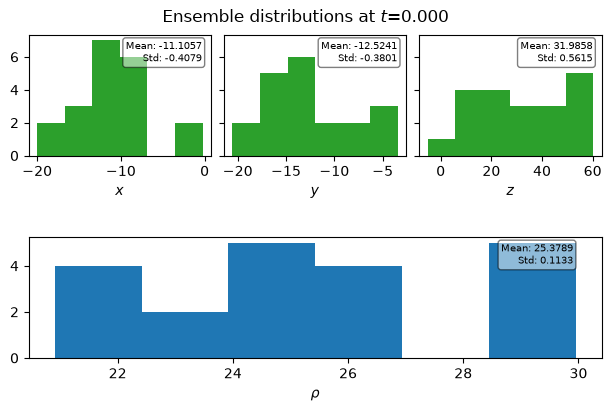

In [3]:
ensemble.visualize_state()

---
## 4. Running the forecast step <a class="anchor" id="forecast"></a>

`forecast_step(t_end=...)` integrates the ensemble forward to `t_end`, appends the result to the model history, and (if a bias is attached) advances the bias model in sync.

```python
estimator.forecast_step(t_end=t_target)
```

The number of integration steps is derived from `t_end` and `model.dt` automatically.  The history grows with each call.

In [4]:
# Integrate forward for 5 Lyapunov times
t_end = ensemble.current_time + 10 * ensemble.model.t_lyap
ensemble.forecast_step(t_end=t_end)

print(f"History length : {len(ensemble.model.hist_t)} steps")
print(f"Time range     : {ensemble.model.hist_t[0]:.2f} --> {ensemble.model.hist_t[-1]:.2f}")
print(f"History shape  : {ensemble.model.hist.shape}  (Nt, Nphi+Na, m)")

Initializing multiprocessing pool for IVPIntegrator with m=20 and 20 pools.


History length : 546 steps
Time range     : 0.00 --> 10.90
History shape  : (546, 4, 20)  (Nt, Nphi+Na, m)


### Visualising the forecast

`visualize_history` plots the ensemble observable history.  The three columns show an early window, a late window, and the full time axis.

/storage0/anovoama/romda/src/estimators/ensembles.py:890: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig1.legend(loc='center', bbox_to_anchor=(0.5, 1.05), ncol=6, frameon=False)


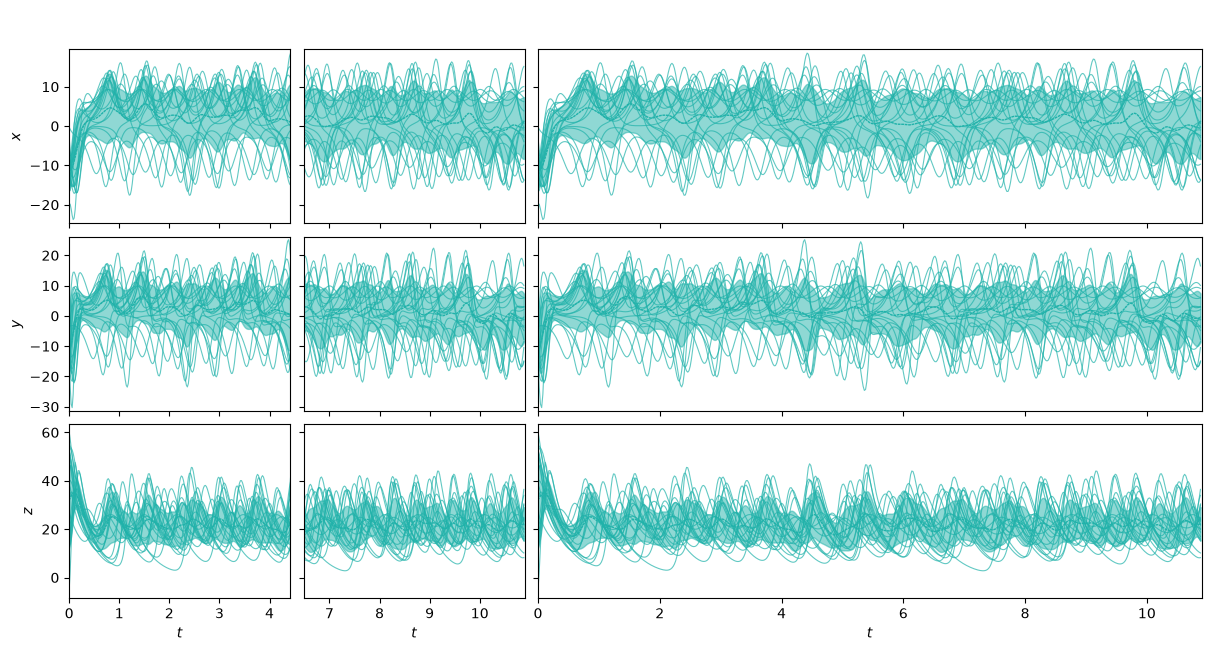

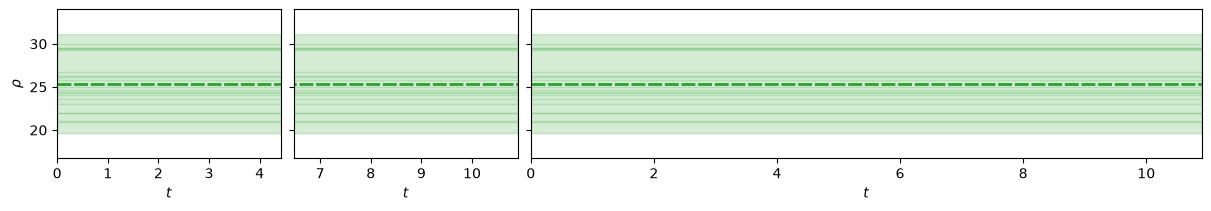

In [5]:
ensemble.visualize_history(plot_members=True)